In [8]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import CountVectorizer

# Ensure NLTK components are available
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /Users/dp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/dp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/dp/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/dp/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/dp/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/dp/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [2]:
with open("sun.txt", "r") as file:
    raw_text = file.read()

In [3]:
print(raw_text)

The Sun shines brightly in the sky.
The Sun gives heat to Earth.
Plants grow with sunlight.
The Sun rises every morning.
The Sun sets every evening.
The Sun is a giant star.
Earth moves around the Sun.
The Sun provides energy.
Sunlight helps plants make food.
The Sun appears yellow.
The Sun is very hot.
The Sun lights up the daytime sky.
The Sun is larger than Earth.
The Sun has strong gravity.
The Sun produces solar energy.
The Sun keeps planets in orbit.
The Sun is at the center of the solar system.
The Sun contains hydrogen gas.
The Sun also contains helium gas.
The Sun creates warmth on Earth.
The Sun helps control weather.
The Sun supports life on Earth.
The Sun shines every day.
The Sun is millions of miles away.
The Sun has a hot core.
The Sun produces light through fusion.
The Sun can cause solar flares.
The Sun has a glowing surface.
The Sun is important to nature.
The Sun affects Earth’s climate.
The Sun helps make daytime bright.
The Sun is part of the Milky Way galaxy.
The 

In [4]:
sentences = raw_text.strip().split('\n')
df = pd.DataFrame(sentences, columns=['original'])
df.head()

,original
0,The Sun shines brightly in the sky.
1,The Sun gives heat to Earth.
2,Plants grow with sunlight.
3,The Sun rises every morning.
4,The Sun sets every evening.


In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punct_table = str.maketrans('', '', string.punctuation)

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default to noun

def preprocess(text):
    tokens = word_tokenize(text)
    print(f"Tokens: {tokens}")  # Debugging line

    tokens = [t.lower().translate(punct_table) for t in tokens if t.isalnum()]
    print(f"Tokens after punctuation removal: {tokens}")  #
    
    tokens = [t for t in tokens if t not in stop_words]
    print(f"Tokens after stopword removal: {tokens}")  # Debugging line

    pos_tags = pos_tag(tokens)
    print(f"POS tags: {pos_tags}")

    tokens = [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in pos_tags]
    print(f"Tokens after lemmatization: {tokens}")  # Debugging line
    print("")

    return ' '.join(tokens)

In [6]:
df['cleaned'] = df['original'].apply(preprocess)

Tokens: ['The', 'Sun', 'shines', 'brightly', 'in', 'the', 'sky', '.']
Tokens after punctuation removal: ['the', 'sun', 'shines', 'brightly', 'in', 'the', 'sky']
Tokens after stopword removal: ['sun', 'shines', 'brightly', 'sky']
POS tags: [('sun', 'NN'), ('shines', 'NNS'), ('brightly', 'RB'), ('sky', 'VBP')]
Tokens after lemmatization: ['sun', 'shine', 'brightly', 'sky']

Tokens: ['The', 'Sun', 'gives', 'heat', 'to', 'Earth', '.']
Tokens after punctuation removal: ['the', 'sun', 'gives', 'heat', 'to', 'earth']
Tokens after stopword removal: ['sun', 'gives', 'heat', 'earth']
POS tags: [('sun', 'NN'), ('gives', 'VBZ'), ('heat', 'NN'), ('earth', 'NN')]
Tokens after lemmatization: ['sun', 'give', 'heat', 'earth']

Tokens: ['Plants', 'grow', 'with', 'sunlight', '.']
Tokens after punctuation removal: ['plants', 'grow', 'with', 'sunlight']
Tokens after stopword removal: ['plants', 'grow', 'sunlight']
POS tags: [('plants', 'NNS'), ('grow', 'VB'), ('sunlight', 'NN')]
Tokens after lemmatization:

In [7]:
df

,original,cleaned
0,The Sun shines brightly in the sky.,sun shine brightly sky
1,The Sun gives heat to Earth.,sun give heat earth
2,Plants grow with sunlight.,plant grow sunlight
3,The Sun rises every morning.,sun rise every morning
4,The Sun sets every evening.,sun set every evening
5,The Sun is a giant star.,sun giant star
6,Earth moves around the Sun.,earth move around sun
7,The Sun provides energy.,sun provide energy
8,Sunlight helps plants make food.,sunlight help plant make food
9,The Sun appears yellow.,sun appear yellow


In [16]:
vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(df['cleaned'])
bow_df = pd.DataFrame(bow.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

,affect,also,appear,around,atmosphere,away,beautiful,billion,bright,brightly,...,visible,warms,warmth,water,way,weather,wind,without,year,yellow
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


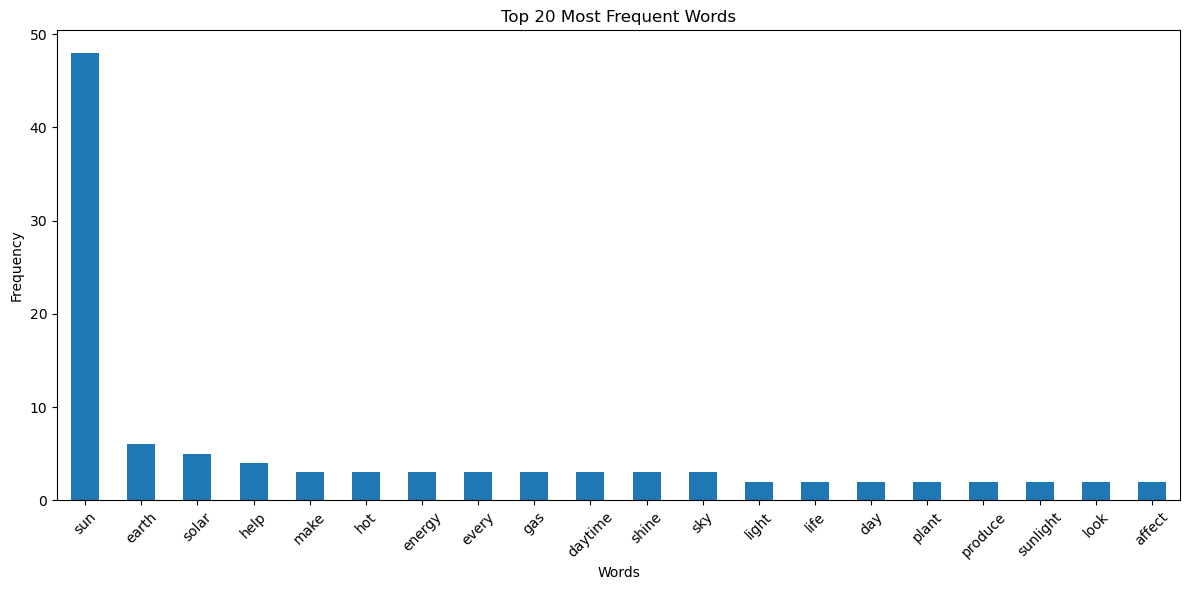

In [19]:
import matplotlib.pyplot as plt

word_freq = bow_df.sum().sort_values(ascending=False)

# Select top 20 words
top_n = 20
top_words = word_freq.head(top_n)

# Plot
plt.figure(figsize=(12, 6))
top_words.plot(kind='bar')
plt.title(f"Top {top_n} Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. How did preprocessing change your text?

- The preprocessing tokenized the text, coverted words to lowercase, removed punctuation, removed stopwords, tagged part-of-speech, and lemmatized.

2. Which words appeared most often in your Bag of Words output?

- Sun appeared the most, followed distantly by earth and solar. This makes sense as I prompted chatgpt to give me 50 lines about the sun.

3. Why might Bag of Words be useful for machine learning?

- This can be useful for model training and testing so that a model can predict what words are likely to follow other words. This is how LLM's work as far as I understand.